In [1]:
import pandas as pd
import numpy as np
from pgmpy.models import BayesianModel
from pgmpy.models import BayesianNetwork
from pgmpy.inference import VariableElimination, ApproxInference, BeliefPropagation
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.estimators import BayesianEstimator
from pgmpy.estimators import HillClimbSearch
from pgmpy.estimators import BDeuScore, K2Score, BicScore
from pgmpy.metrics import structure_score
from pgmpy.utils import get_example_model
from pgmpy.estimators import ScoreCache
from pgmpy.inference.CausalInference import CausalInference
import networkx as nx
import bnlearn as bn
import itertools
import math
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
from same_decision_probability_calculation import *
from minimum_information_loss_partition import *
from utils import *

from monte_carlo_sdp import *

In [3]:
from pgmpy.utils import get_example_model

In [4]:
alarm_model = get_example_model('alarm')
child_model = get_example_model('child')
asia_model = get_example_model('asia')
insurance_model = get_example_model('insurance')
hailfinder_model = get_example_model('hailfinder')
hepar_model = get_example_model('hepar2')

In [5]:
state_mapping = {'yes': 1, 'no': 0, 'True': 1, 'False': 0, 'TRUE':0, 'FALSE':1, 'present': 1, 'absent': 0, 'Present': 1, 'Absent': 0}
# Iterate through every CPD in the model
for cpd in asia_model.get_cpds():
    new_state_names = {}
    new_name_to_no = {}
    
    for var, states in cpd.state_names.items():
        # Map the old states ('yes'/'no') to the new states (1/0)
        # If a state isn't in our mapping, it stays the same
        new_states = [state_mapping.get(state, state) for state in states]
        
        # Update the dictionaries
        new_state_names[var] = new_states
        new_name_to_no[var] = {state: idx for idx, state in enumerate(new_states)}
        
    # Assign the updated dictionaries back to the CPD
    cpd.state_names = new_state_names
    cpd.name_to_no = new_name_to_no

for cpd in child_model.get_cpds():
    new_state_names = {}
    new_name_to_no = {}
    
    for var, states in cpd.state_names.items():
        # Map the old states ('yes'/'no') to the new states (1/0)
        # If a state isn't in our mapping, it stays the same
        new_states = [state_mapping.get(state, state) for state in states]
        
        # Update the dictionaries
        new_state_names[var] = new_states
        new_name_to_no[var] = {state: idx for idx, state in enumerate(new_states)}
        
    # Assign the updated dictionaries back to the CPD
    cpd.state_names = new_state_names
    cpd.name_to_no = new_name_to_no

for cpd in alarm_model.get_cpds():
    new_state_names = {}
    new_name_to_no = {}
    
    for var, states in cpd.state_names.items():
        # Map the old states ('yes'/'no') to the new states (1/0)
        # If a state isn't in our mapping, it stays the same
        new_states = [state_mapping.get(state, state) for state in states]
        
        # Update the dictionaries
        new_state_names[var] = new_states
        new_name_to_no[var] = {state: idx for idx, state in enumerate(new_states)}
        
    # Assign the updated dictionaries back to the CPD
    cpd.state_names = new_state_names
    cpd.name_to_no = new_name_to_no

for cpd in insurance_model.get_cpds():
    new_state_names = {}
    new_name_to_no = {}
    
    for var, states in cpd.state_names.items():
        # Map the old states ('yes'/'no') to the new states (1/0)
        # If a state isn't in our mapping, it stays the same
        new_states = [state_mapping.get(state, state) for state in states]
        
        # Update the dictionaries
        new_state_names[var] = new_states
        new_name_to_no[var] = {state: idx for idx, state in enumerate(new_states)}
        
    # Assign the updated dictionaries back to the CPD
    cpd.state_names = new_state_names
    cpd.name_to_no = new_name_to_no

for cpd in hailfinder_model.get_cpds():
    new_state_names = {}
    new_name_to_no = {}
    
    for var, states in cpd.state_names.items():
        # Map the old states ('yes'/'no') to the new states (1/0)
        # If a state isn't in our mapping, it stays the same
        new_states = [state_mapping.get(state, state) for state in states]
        
        # Update the dictionaries
        new_state_names[var] = new_states
        new_name_to_no[var] = {state: idx for idx, state in enumerate(new_states)}
        
    # Assign the updated dictionaries back to the CPD
    cpd.state_names = new_state_names
    cpd.name_to_no = new_name_to_no

for cpd in hepar_model.get_cpds():
    new_state_names = {}
    new_name_to_no = {}
    
    for var, states in cpd.state_names.items():
        # Map the old states ('yes'/'no') to the new states (1/0)
        # If a state isn't in our mapping, it stays the same
        new_states = [state_mapping.get(state, state) for state in states]
        
        # Update the dictionaries
        new_state_names[var] = new_states
        new_name_to_no[var] = {state: idx for idx, state in enumerate(new_states)}
        
    # Assign the updated dictionaries back to the CPD
    cpd.state_names = new_state_names
    cpd.name_to_no = new_name_to_no

# --- Verification ---
# Let's print the CPD for the 'asia' node to confirm the change
print(asia_model.get_cpds('asia'))

+---------+------+
| asia(1) | 0.01 |
+---------+------+
| asia(0) | 0.99 |
+---------+------+


# Import MAGABN network and data

In [6]:
bn1 = nx.read_gml("/home/joao/Desktop/UFMG/PhD/code/explaining-BN/models/complete_data_best_graph_fold_1.gml")
new_names = {
    "sexo_M": "Sex",
    "grupo_idade": "Age",
    "teve_ec": "CoronaryDisease",
    "imc": "BMI",
    "_64": "Question_64",
    "_66": "Question_66",
    "_58": "Question_58",
    "_59": "Question_59",
    "_76": "Question_76",
    "_77": "Question_77",
}


bn1 = nx.relabel_nodes(bn1, new_names)
bn1 = BayesianNetwork(bn1.edges())

In [7]:
data = pd.read_csv("../data/data_"+"ec"+"_filtered.csv")
data = data.rename(columns=new_names)
data.BMI = pd.qcut(data.BMI, q=10, duplicates='drop')
data.Age = pd.qcut(data.Age, q=10, duplicates='drop')

In [8]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)
folds = list(kf.split(data))
train_index, test_index = folds[0]
train_data = data.iloc[train_index]
test_data = data.iloc[test_index]

bn1.fit(train_data, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)

# Effect of partitions using one case patient

In [75]:
# interesting case patient
patient_interesting = {'cod_Z95': 0,
 'cod_E10': 1,
 'Question_59': 1,
 'cod_I42': 0,
 'cod_E14': 1,
 'cod_I27': 0,
 'Question_76': 1,
 'cod_J44': 0,
 'Sex': 1,
 'BMI': pd.Interval(29.758, 210.039, closed='right'),
 'cod_B57': 0,
 'cod_I49': 0,
 'cod_I34': 0,
 'Question_64': 1,
 'cod_F41': 0,
 'cod_E11': 0,
 'Question_77': 1,
 'cod_I47': 0,
 'cod_I50': 0,
 'cod_I35': 0}

In [9]:
# Probability P(CAD=1 | patient_interesting)
inference = VariableElimination(bn1)
prob_cad_1 = inference.query(variables=['CoronaryDisease'], evidence=patient_interesting, show_progress=False)
print(f"P(CAD=1 | patient_interesting) = {prob_cad_1.get_value(CoronaryDisease=1):.4f}")

P(CAD=1 | patient_interesting) = 0.9221


In [76]:
H = [v for v in bn1.nodes() if v not in patient_interesting and v != 'CoronaryDisease']
partitions = get_partitions(bn1, H, 'CoronaryDisease', patient_interesting)
#sdp = optimized_tree_search_sdp(bn1, 'CoronaryDisease', 1, patient, 0.8, partitions)
sdp = fast_broadcast_sdp(bn1, 'CoronaryDisease', 1, patient_interesting, 0.8, partitions)
print(f"SDP for generated patient: {sdp:.4f}")

SDP for generated patient: 0.7558


In [15]:
# Artificial Naive Bayes: force each variable to be in its own partition
partitions_nb = [[v] for v in H]
sdp_nb = fast_broadcast_sdp(bn1, 'CoronaryDisease', 1, patient_interesting, 0.8, partitions_nb)
print(f"SDP for generated patient with Naive Bayes partition: {sdp_nb:.4f}")

SDP for generated patient with Naive Bayes partition: 0.9515


SDP values for different thresholds with Naive Bayes partition:
Threshold: 0.3, SDP: 0.9949
Threshold: 0.35, SDP: 0.9735
Threshold: 0.4, SDP: 0.9670
Threshold: 0.45, SDP: 0.9610
Threshold: 0.5, SDP: 0.9594
Threshold: 0.55, SDP: 0.9592
Threshold: 0.6, SDP: 0.9583
Threshold: 0.65, SDP: 0.9569
Threshold: 0.7, SDP: 0.9567
Threshold: 0.75, SDP: 0.9565
Threshold: 0.8, SDP: 0.9515
Threshold: 0.85, SDP: 0.7669
Threshold: 0.9, SDP: 0.7133
Threshold: 0.95, SDP: 0.3446


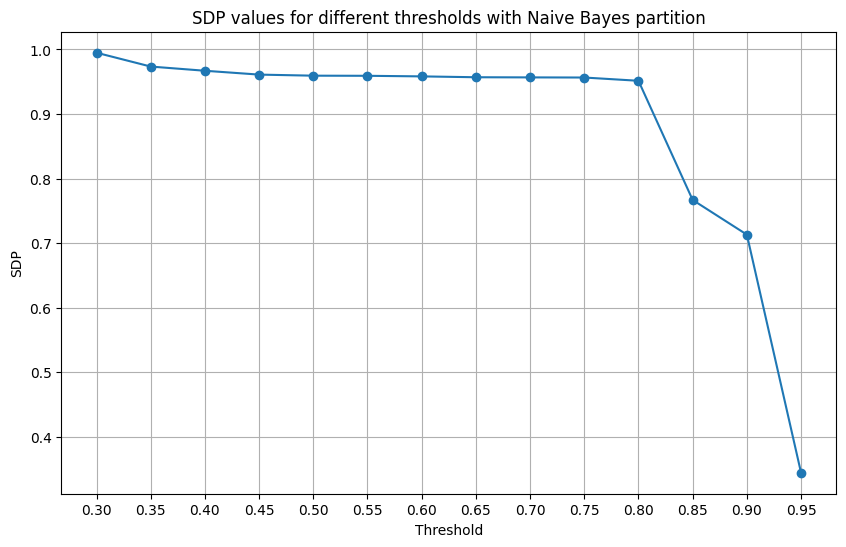

In [11]:
# Check effect of threshold on artificial Naive Bayes partition
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
sdp_nb_thresholds = []
for threshold in thresholds:
    sdp_nb_threshold = fast_broadcast_sdp(bn1, 'CoronaryDisease', 1, patient_interesting, threshold, partitions_nb)
    sdp_nb_thresholds.append(sdp_nb_threshold)
print("SDP values for different thresholds with Naive Bayes partition:")
for threshold, sdp_value in zip(thresholds, sdp_nb_thresholds):
    print(f"Threshold: {threshold}, SDP: {sdp_value:.4f}")

# Plot SDP values for different thresholds with Naive Bayes partition
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(thresholds, sdp_nb_thresholds, marker='o')
plt.title('SDP values for different thresholds with Naive Bayes partition')
plt.xlabel('Threshold')
plt.ylabel('SDP')
plt.xticks(thresholds)
plt.grid()
plt.show()

In [ ]:
# generate random patient
def generate_random_patient(n_evidence = 20):
    evidence = {}
    for _ in range(n_evidence):
        var = np.random.choice(H)
        value = np.random.choice(bn1.get_cpds(var).state_names[var])
        evidence[var] = value
    return evidence

random_patient = generate_random_patient()
print(f"Random patient evidence: {random_patient}")

Random patient evidence: {'cod_Z13': 0, 'cod_R07': 1, 'cod_I11': 1, 'cod_I48': 0, 'cod_E66': 1, 'cod_E03': 0, 'cod_E78': 1, 'cod_I44': 1, 'cod_R00': 1, 'cod_G47': 1, 'Age': Interval(1950.0, 1960.0, closed='right')}


: 

In [ ]:
# Measure SPD error accross 20 random patients using artificial naive bayes partition
sdp_errors_nb = []
for i in range(20):
    random_patient = generate_random_patient(n_evidence=22)
    H = [v for v in bn1.nodes() if v not in random_patient and v != 'CoronaryDisease']
    partitions_nb = [[v] for v in H]
    exact_partitions = get_partitions(bn1, H, 'CoronaryDisease', random_patient)
    print("Size of biggest partition for exact partitions:", max(len(partition) for partition in exact_partitions))
    sdp_nb_random = fast_broadcast_sdp(bn1, 'CoronaryDisease', 1, random_patient, 0.8, partitions_nb)
    sdp_exact_random = fast_broadcast_sdp(bn1, 'CoronaryDisease', 1, random_patient, 0.8, exact_partitions)
    sdp_error_nb = abs(sdp_nb_random - sdp_exact_random)
    sdp_errors_nb.append(sdp_error_nb)
    print(f"Patient {i+1}: SDP NB = {sdp_nb_random:.4f}, SDP Exact = {sdp_exact_random:.4f}, Error = {sdp_error_nb:.4f}")



Size of biggest partition for exact partitions: 20
Patient 1: SDP NB = 1.0000, SDP Exact = 1.0000, Error = 0.0000
Size of biggest partition for exact partitions: 23
Patient 2: SDP NB = 1.0000, SDP Exact = 1.0000, Error = 0.0000
Size of biggest partition for exact partitions: 14
Patient 3: SDP NB = 0.6660, SDP Exact = 0.5666, Error = 0.0994
Size of biggest partition for exact partitions: 20
Patient 4: SDP NB = 0.6800, SDP Exact = 0.6798, Error = 0.0002
Size of biggest partition for exact partitions: 17
Patient 5: SDP NB = 0.5797, SDP Exact = 0.5333, Error = 0.0464
Size of biggest partition for exact partitions: 21
Patient 6: SDP NB = 0.9752, SDP Exact = 0.8073, Error = 0.1679
Size of biggest partition for exact partitions: 17
Patient 7: SDP NB = 0.9823, SDP Exact = 0.8825, Error = 0.0998
Size of biggest partition for exact partitions: 19
Patient 8: SDP NB = 1.0000, SDP Exact = 1.0000, Error = 0.0000
Size of biggest partition for exact partitions: 20
Patient 9: SDP NB = 0.9735, SDP Exact

example before crash
Size of biggest partition for exact partitions: 20
Patient 1: SDP NB = 1.0000, SDP Exact = 1.0000, Error = 0.0000
Size of biggest partition for exact partitions: 23
Patient 2: SDP NB = 1.0000, SDP Exact = 1.0000, Error = 0.0000
Size of biggest partition for exact partitions: 14
Patient 3: SDP NB = 0.6660, SDP Exact = 0.5666, Error = 0.0994
Size of biggest partition for exact partitions: 20
Patient 4: SDP NB = 0.6800, SDP Exact = 0.6798, Error = 0.0002
Size of biggest partition for exact partitions: 17
Patient 5: SDP NB = 0.5797, SDP Exact = 0.5333, Error = 0.0464
Size of biggest partition for exact partitions: 21
Patient 6: SDP NB = 0.9752, SDP Exact = 0.8073, Error = 0.1679
Size of biggest partition for exact partitions: 17
Patient 7: SDP NB = 0.9823, SDP Exact = 0.8825, Error = 0.0998
Size of biggest partition for exact partitions: 19
Patient 8: SDP NB = 1.0000, SDP Exact = 1.0000, Error = 0.0000
Size of biggest partition for exact partitions: 20
Patient 9: SDP NB = 0.9735, SDP Exact = 0.7865, Error = 0.1870
Size of biggest partition for exact partitions: 13
Patient 10: SDP NB = 1.0000, SDP Exact = 1.0000, Error = 0.0000
Size of biggest partition for exact partitions: 6
Patient 11: SDP NB = 1.0000, SDP Exact = 1.0000, Error = 0.0000
Size of biggest partition for exact partitions: 24

In [ ]:
def generate_n_random_partitions(H, n, variables_per_partition=3):
    random_partitions_list = []
    for _ in range(n):
        random_partition = []
        H_copy = H.copy()
        np.random.shuffle(H_copy)
        for i in range(0, len(H_copy), variables_per_partition):
            random_partition.append(H_copy[i:i + variables_per_partition])
        random_partitions_list.append(random_partition)
    return random_partitions_list

SDP for random partitions with 2 variables each: [0.9477083924303801, 0.8353306932203296, 0.9460848535017173, 0.9473014914871487, 0.9435828005274629, 0.9516232079509606, 0.9507320035693397, 0.9475925423578021, 0.946077561233994, 0.9461499951482516, 0.8163878587554904, 0.9507320035693398, 0.9507320035693398, 0.882833041280016, 0.9514906138882391, 0.9442989137593724, 0.9514906138882392, 0.8630517288609675, 0.9514643123821486, 0.9479221062438438, 0.9473014914871488, 0.8828326512208032, 0.9460534360047484, 0.9473086857908595, 0.9371609458225364, 0.9516333120714754, 0.9518728942453503, 0.9370885270516114, 0.9471381435758903, 0.9483075484381173, 0.9384576962769524, 0.9415092399193408, 0.9460848535017172, 0.8855568694789544, 0.9507213837826759, 0.9476158077766895, 0.9516386526399563, 0.9514643123821483, 0.9392963643436184, 0.9323337922755939, 0.9460848535017172, 0.9488567389483086, 0.9473333152865177, 0.9460777250509882, 0.9514643123821483, 0.9161180344489304, 0.8273006195637594, 0.9514546700

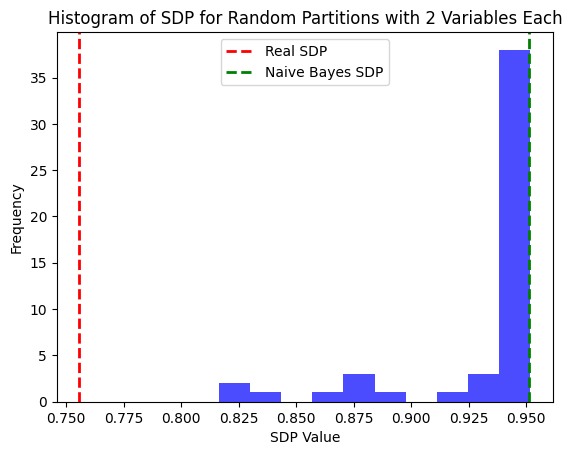

In [ ]:
# Make N random partitions with 2 variables each

random_partitions_list = generate_n_random_partitions(H, 50, variables_per_partition=2)
sdp_pair_partitions = []
for i, random_partition in enumerate(random_partitions_list):
    sdp_random = fast_broadcast_sdp(bn1, 'CoronaryDisease', 1, patient_interesting, 0.8, random_partition)
    sdp_pair_partitions.append(sdp_random)

# Print statistics of SDP for random partitions and plot histogram
print(f"SDP for random partitions with 2 variables each: {sdp_pair_partitions}")
print(f"Mean SDP for random partitions: {np.mean(sdp_pair_partitions):.4f}")
print(f"Max SDP for random partitions: {np.max(sdp_pair_partitions):.4f}")
print(f"Standard deviation of SDP for random partitions: {np.std(sdp_pair_partitions):.4f}")
import matplotlib.pyplot as plt
plt.hist(sdp_pair_partitions, bins=10, alpha=0.7, color='blue')
plt.axvline(sdp, color='red', linestyle='dashed', linewidth=2, label='Real SDP')
plt.axvline(sdp_nb, color='green', linestyle='dashed', linewidth=2, label='Naive Bayes SDP')
plt.title('Histogram of SDP for Random Partitions with 2 Variables Each')
plt.xlabel('SDP Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

SDP for random partitions with 3 variables each: [0.9448503446977556, 0.9424856184430934, 0.9518304930287461, 0.947992508590727, 0.9477123584725319, 0.9486761716364829, 0.816221114850457, 0.8539240047153616, 0.9507755096113742, 0.9505211247407501, 0.9407705207874549, 0.9470973499314345, 0.9417279548818098, 0.8442871819323808, 0.9412267501425626, 0.9514619934451787, 0.9362626838706548, 0.886220579986886, 0.9047035983064287, 0.8181438808362532, 0.9375329482756057, 0.9440004406128801, 0.9462947159409545, 0.937909389565492, 0.833260216572629, 0.8895829366835183, 0.8839949521152463, 0.9442740183596403, 0.8570250581390295, 0.9371924601898657, 0.850349848874612, 0.9116524371193078, 0.9552827901262448, 0.9515146431660867, 0.913019759149818, 0.9466264950375757, 0.94839361690085, 0.8150415367414369, 0.9486258005061077, 0.9522469919210844, 0.9128845824879593, 0.9512856726347532, 0.8498413086225798, 0.8481049245027914, 0.8993266014551864, 0.9442499675353622, 0.9455480926899416, 0.9303075799896986,

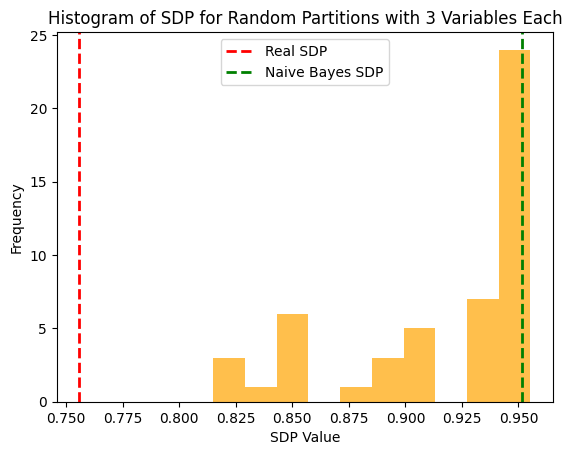

In [ ]:
# random partitions with 3 variables each
random_partitions_list_3 = generate_n_random_partitions(H, 50, variables_per_partition=3)
sdp_triple_partitions = []
for i, random_partition in enumerate(random_partitions_list_3):
    sdp_random = fast_broadcast_sdp(bn1, 'CoronaryDisease', 1, patient_interesting, 0.8, random_partition)
    sdp_triple_partitions.append(sdp_random)
print(f"SDP for random partitions with 3 variables each: {sdp_triple_partitions}")
print(f"Mean SDP for random partitions with 3 variables each: {np.mean(sdp_triple_partitions):.4f}")
print(f"Standard deviation of SDP for random partitions with 3 variables each: {np.std(sdp_triple_partitions):.4f}")
plt.hist(sdp_triple_partitions, bins=10, alpha=0.7, color='orange')
plt.axvline(sdp, color='red', linestyle='dashed', linewidth=2, label='Real SDP')
plt.axvline(sdp_nb, color='green', linestyle='dashed', linewidth=2, label='Naive Bayes SDP')
plt.title   ('Histogram of SDP for Random Partitions with 3 Variables Each')
plt.xlabel('SDP Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
np.max(sdp_pair_partitions), np.min(sdp_pair_partitions), np.max(sdp_triple_partitions), np.min(sdp_triple_partitions)

(0.9527861952092336,
 0.8038076142929624,
 0.9552827901262448,
 0.8150415367414369)

In [ ]:
sdp_nb

0.9514643123821485

# Monte Carlo Estimations

In [12]:
#experiment_patients_child = find_exact_experimental_patients(child_model, 'Sick', 1, 0.5, hidden_size=10)

In [16]:
# save experiment patients to json
#import json
#with open('experiment_patients_child.json', 'w') as f:
#    json.dump(experiment_patients_child, f, indent=4, default=int)

In [ ]:
def run_variance_experiment(bn, target, target_value, threshold, experimental_patients, trials=20, mc_samples=11000):
    results = []
    
    for bucket, data in experimental_patients.items():
        true_sdp = data['true_sdp']
        evidence = data['evidence']
        print(f"\nRunning {trials} MC trials for patient with Exact SDP: {true_sdp:.4f}...")
        
        for trial in range(trials):
            est_sdp = mcmc_sdp_estimation(bn, target, target_value, evidence, threshold, n_samples=mc_samples, burn_in=1000, thinning=10)
            error = est_sdp - true_sdp
            
            results.append({
                'True_SDP': true_sdp,
                'Estimated_SDP': est_sdp,
                'Error': error,
                'Bucket': bucket
            })
            
    return pd.DataFrame(results)

## Child

In [37]:
import json
experiment_patients_child = json.load(open("./experiment_patients_child.json", "r"))

In [39]:
child_results = run_variance_experiment(child_model, 'Sick', 1, 0.5, experiment_patients_child, trials=20, mc_samples=100)



Running 20 MC trials for patient with Exact SDP: 0.8936...

Running 20 MC trials for patient with Exact SDP: 0.4936...

Running 20 MC trials for patient with Exact SDP: 0.6946...

Running 20 MC trials for patient with Exact SDP: 0.9100...

Running 20 MC trials for patient with Exact SDP: 0.2796...

Running 20 MC trials for patient with Exact SDP: 0.8469...

Running 20 MC trials for patient with Exact SDP: 0.1848...


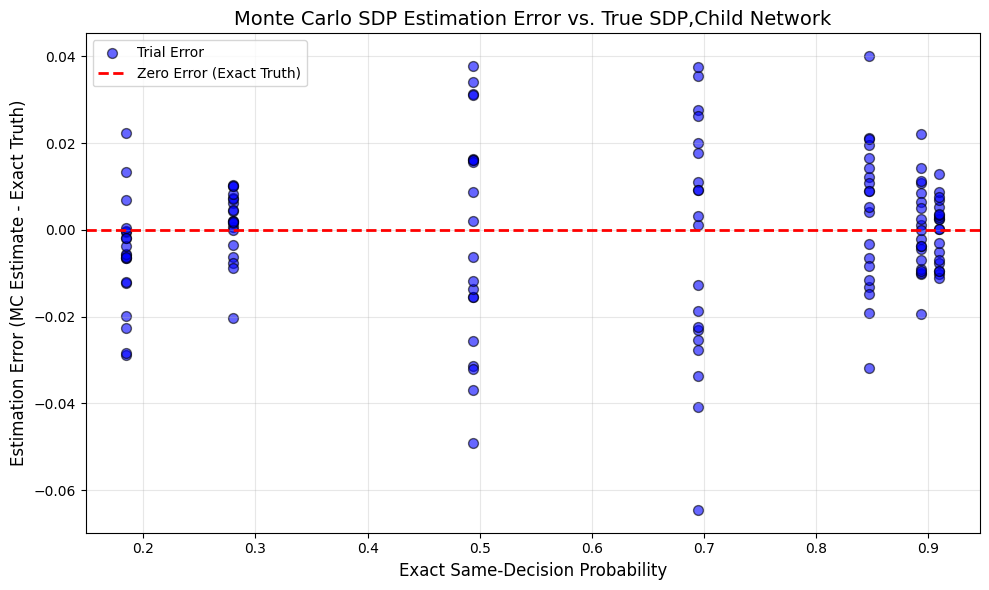

In [ ]:
plot_experiment_results(child_results, 'Child')

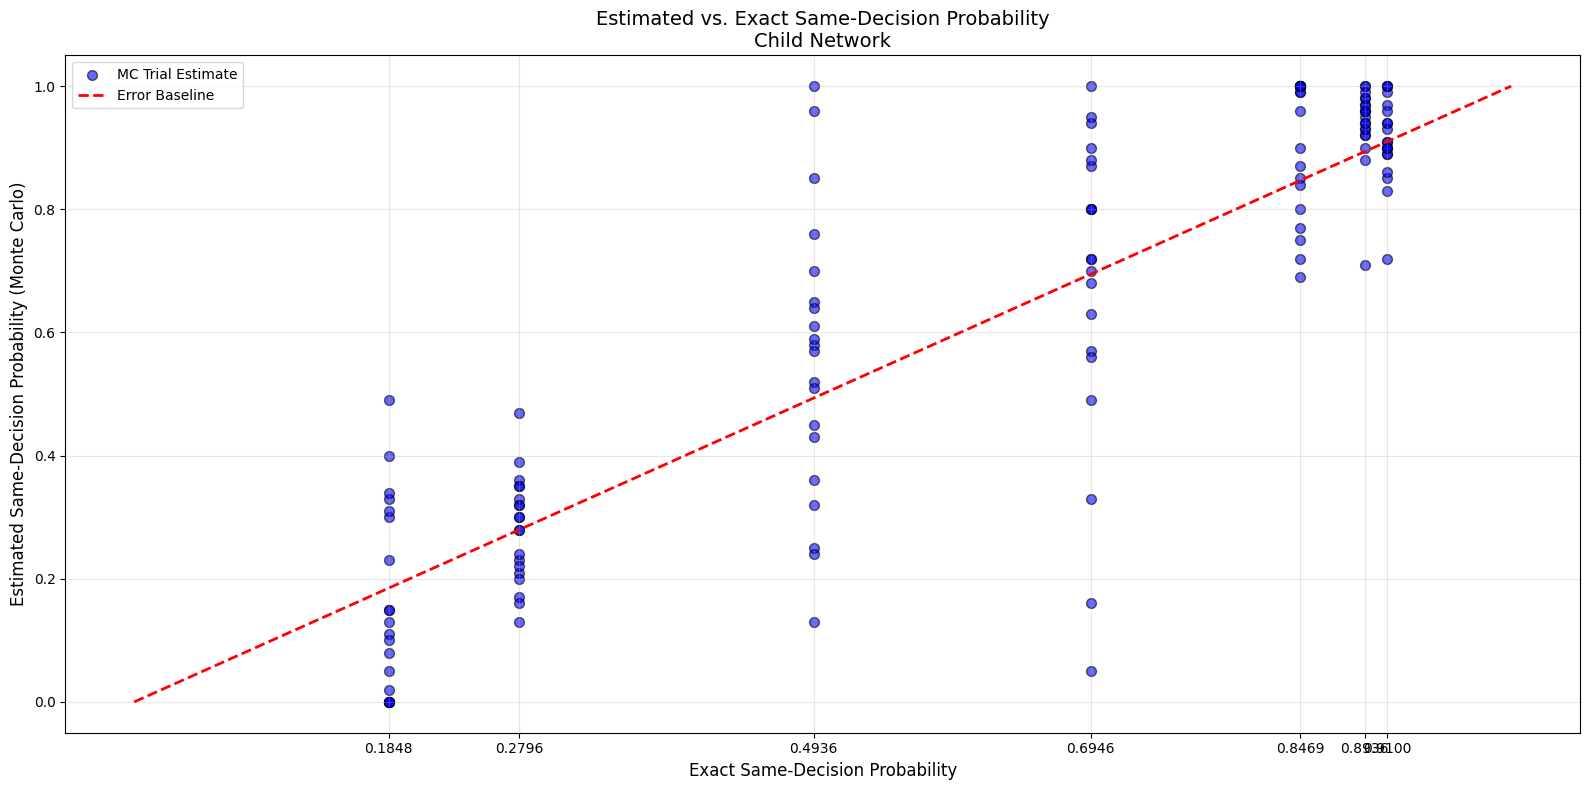

In [40]:
plot_experiment_results_exact_vs_est(child_results, 'Child')

## Alarm

In [6]:
# get binary variables from alarm model
binary_vars_alarm = [var for var in alarm_model.nodes() if len(alarm_model.get_cpds(var).state_names[var]) == 2]
print(f"Binary variables in Alarm model: {binary_vars_alarm}")

Binary variables in Alarm model: ['HISTORY', 'HYPOVOLEMIA', 'LVFAILURE', 'ERRLOWOUTPUT', 'ERRCAUTER', 'INSUFFANESTH', 'ANAPHYLAXIS', 'KINKEDTUBE', 'FIO2', 'PULMEMBOLUS', 'SHUNT', 'DISCONNECT', 'CATECHOL']


In [7]:
alarm_model.get_cpds('LVFAILURE').state_names['LVFAILURE']

[0, 1]

In [8]:
def generate_patient_evidence(model, target, latent_size=10):
    all_variables = model.nodes()

    possible_evidence_vars = [v for v in all_variables if v != target]
    num_observed = len(all_variables) - latent_size - 1
    observed_vars = random.sample(possible_evidence_vars, num_observed)
    
    evidence = {}
    for var in observed_vars:
        # Fetch valid states for this specific variable from the BN
        valid_states = model.get_cpds(var).state_names[var]
        evidence[var] = random.choice(valid_states)
        
    return evidence

In [14]:
len(alarm_model.nodes())

37

In [9]:
individual = generate_patient_evidence(alarm_model, 'LVFAILURE', 32)

In [10]:
inference = VariableElimination(alarm_model)
base_dist = inference.query(variables=['LVFAILURE'], evidence=individual, show_progress=False)
print(base_dist)

+--------------+------------------+
| LVFAILURE    |   phi(LVFAILURE) |
+==============+==================+
| LVFAILURE(0) |           0.8257 |
+--------------+------------------+
| LVFAILURE(1) |           0.1743 |
+--------------+------------------+


In [11]:
sdp_individual = mcmc_sdp_estimation(alarm_model, 'LVFAILURE', 1, individual, 0.5)
print(sdp_individual)

0.29554545454545456


In [ ]:
#hidden_vars = [v for v in alarm_model.nodes() if v not in individual and v != 'LVFAILURE']
#partitions = get_partitions(alarm_model, hidden_vars, 'LVFAILURE', individual)
#sdp_individual_exact = fast_broadcast_sdp(alarm_model, 'LVFAILURE', 1, individual, 0.5, partitions)

# CRASHES

: 

In [ ]:
experiment_patients_alarm = find_exact_experimental_patients(alarm_model, 'LVFAILURE', 1, 0.5, hidden_size=10, buckets=[0.3, 0.5, 0.7, 0.8, 0.9, 0.95])

Hunting for patients... (Locking 26 variables as evidence)
Generating a batch of 5000 random realities...
--> Filled bucket 0.95 with Exact SDP: 1.0000
--> Filled bucket 0.9 with Exact SDP: 0.9339
--> Filled bucket 0.8 with Exact SDP: 0.8378
--> Filled bucket 0.7 with Exact SDP: 0.6579
--> Filled bucket 0.5 with Exact SDP: 0.5183
Generating a batch of 5000 random realities...
--> Filled bucket 0.3 with Exact SDP: 0.2938
All buckets filled successfully!


In [30]:
alarm_results = run_variance_experiment(alarm_model, 'LVFAILURE', 1, 0.5, experiment_patients_alarm, trials=20, mc_samples=1000)   


Running 20 MC trials for patient with Exact SDP: 1.0000...

Running 20 MC trials for patient with Exact SDP: 0.9339...

Running 20 MC trials for patient with Exact SDP: 0.8378...

Running 20 MC trials for patient with Exact SDP: 0.6579...

Running 20 MC trials for patient with Exact SDP: 0.5183...

Running 20 MC trials for patient with Exact SDP: 0.2938...


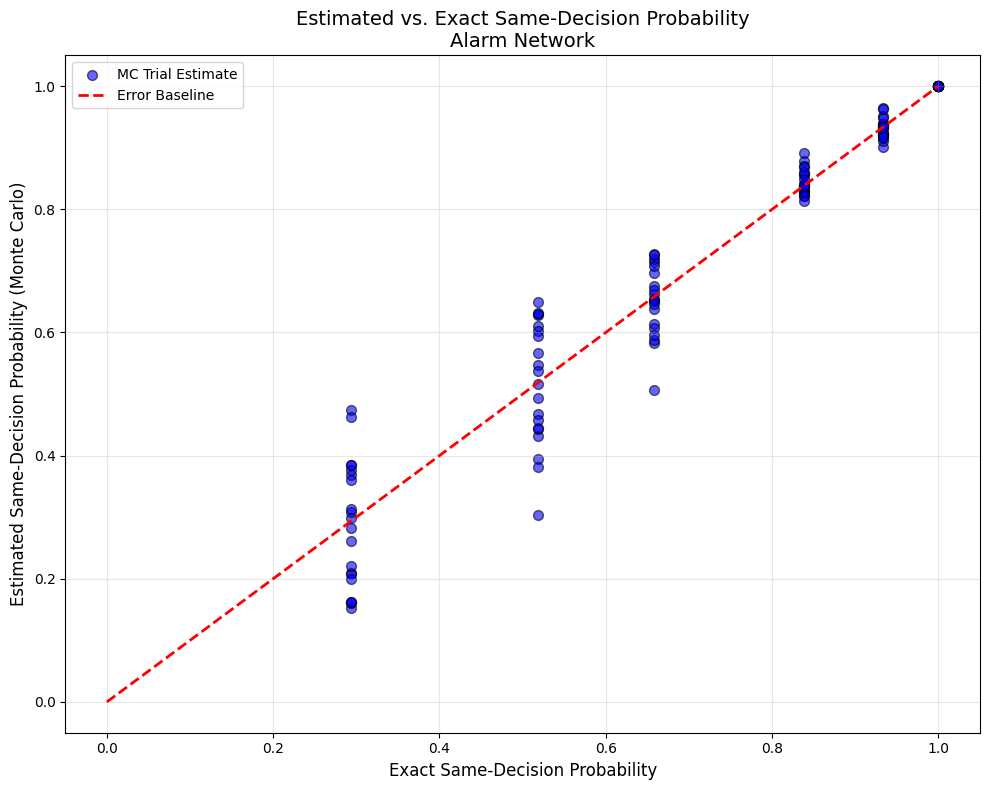

In [31]:
plot_experiment_results_exact_vs_est(alarm_results, 'Alarm')

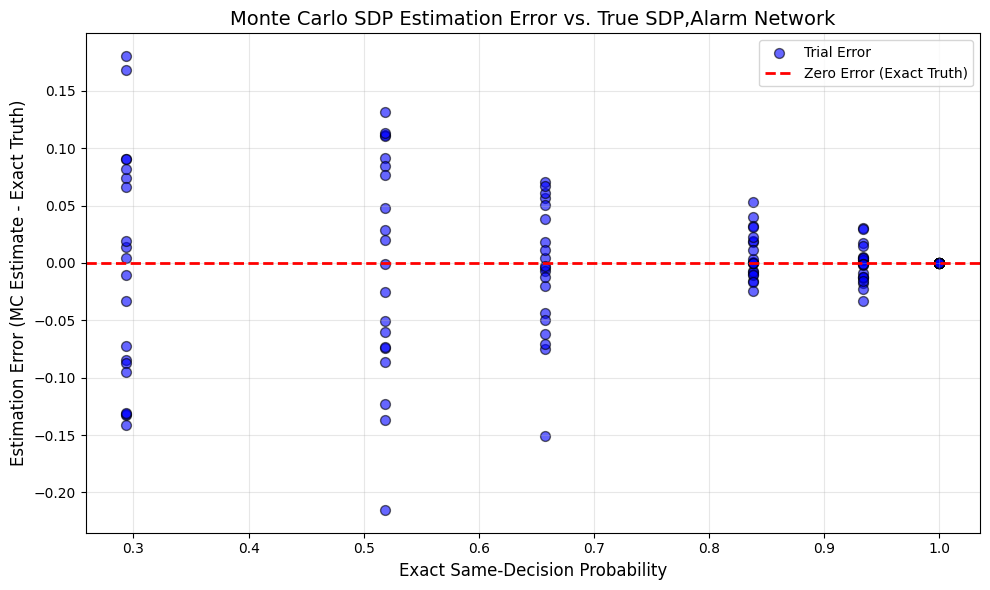

In [33]:
plot_experiment_results(alarm_results, 'Alarm')

## Hailfinder

In [11]:
binary_vars_hailfinder = [var for var in hailfinder_model.nodes() if len(hailfinder_model.get_cpds(var).state_names[var]) == 2]
print(f"Binary variables in Hailfinder model: {binary_vars_hailfinder}")

Binary variables in Hailfinder model: ['ScenRelAMCIN', 'WindFieldMt']


In [12]:
for var in hailfinder_model.nodes():
    num_states = len(hailfinder_model.get_cpds(var).state_names[var])
    print(f"Variable: {var}, Number of states: {num_states}, States: {hailfinder_model.get_cpds(var).state_names[var]}")

Variable: N0_7muVerMo, Number of states: 4, States: ['StrongUp', 'WeakUp', 'Neutral', 'Down']
Variable: SubjVertMo, Number of states: 4, States: ['StronUp', 'WeakUp', 'Neutral', 'Down']
Variable: QGVertMotion, Number of states: 4, States: ['StrongUp', 'WeakUp', 'Neutral', 'Down']
Variable: CombVerMo, Number of states: 4, States: ['StrongUp', 'WeakUp', 'Neutral', 'Down']
Variable: AreaMeso_ALS, Number of states: 4, States: ['StrongUp', 'WeakUp', 'Neutral', 'Down']
Variable: SatContMoist, Number of states: 4, States: ['VeryWet', 'Wet', 'Neutral', 'Dry']
Variable: RaoContMoist, Number of states: 4, States: ['VeryWet', 'Wet', 'Neutral', 'Dry']
Variable: CombMoisture, Number of states: 4, States: ['VeryWet', 'Wet', 'Neutral', 'Dry']
Variable: AreaMoDryAir, Number of states: 4, States: ['VeryWet', 'Wet', 'Neutral', 'Dry']
Variable: VISCloudCov, Number of states: 3, States: ['Cloudy', 'PC', 'Clear']
Variable: IRCloudCover, Number of states: 3, States: ['Cloudy', 'PC', 'Clear']
Variable: CombC

## HEPAR

In [7]:
binary_vars_hepar = [var for var in hepar_model.nodes() if len(hepar_model.get_cpds(var).state_names[var]) == 2]
print(f"Binary variables in Hepar model: {binary_vars_hepar}")

Binary variables in Hepar model: ['alcoholism', 'vh_amn', 'hepatotoxic', 'THepatitis', 'hospital', 'surgery', 'gallstones', 'choledocholithotomy', 'injections', 'transfusion', 'sex', 'PBC', 'fibrosis', 'diabetes', 'obesity', 'Steatosis', 'Hyperbilirubinemia', 'RHepatitis', 'fatigue', 'itching', 'upper_pain', 'fat', 'pain_ruq', 'pressure_ruq', 'skin', 'ama', 'le_cells', 'joints', 'pain', 'proteins', 'edema', 'bleeding', 'flatulence', 'alcohol', 'encephalopathy', 'ascites', 'hepatomegaly', 'hepatalgia', 'density', 'hbsag', 'hbsag_anti', 'anorexia', 'nausea', 'spleen', 'consciousness', 'spiders', 'jaundice', 'edge', 'irregular_liver', 'hbc_anti', 'hcv_anti', 'palms', 'hbeag', 'carcinoma']


In [8]:
for var in hepar_model.nodes():
    num_states = len(hepar_model.get_cpds(var).state_names[var])
    print(f"Variable: {var}, Number of states: {num_states}, States: {hepar_model.get_cpds(var).state_names[var]}")

Variable: alcoholism, Number of states: 2, States: [1, 0]
Variable: vh_amn, Number of states: 2, States: [1, 0]
Variable: hepatotoxic, Number of states: 2, States: [1, 0]
Variable: THepatitis, Number of states: 2, States: [1, 0]
Variable: hospital, Number of states: 2, States: [1, 0]
Variable: surgery, Number of states: 2, States: [1, 0]
Variable: gallstones, Number of states: 2, States: [1, 0]
Variable: choledocholithotomy, Number of states: 2, States: [1, 0]
Variable: injections, Number of states: 2, States: [1, 0]
Variable: transfusion, Number of states: 2, States: [1, 0]
Variable: ChHepatitis, Number of states: 3, States: ['active', 'persistent', 0]
Variable: sex, Number of states: 2, States: ['female', 'male']
Variable: age, Number of states: 4, States: ['age65_100', 'age51_65', 'age31_50', 'age0_30']
Variable: PBC, Number of states: 2, States: [1, 0]
Variable: fibrosis, Number of states: 2, States: [1, 0]
Variable: diabetes, Number of states: 2, States: [1, 0]
Variable: obesity, 

In [91]:
experiment_patients_hepar = build_experimental_dataset(hepar_model, 'THepatitis', 1, 0.5, hidden_size=14, buckets=[0.5, 0.8, 0.95])


=== Generating patient for target SDP bucket: 0.5 ===

--- Hunting for Patient with SDP ≈ 0.5 ---
Starting random patient SDP: 0.9981 (Error: 0.4981)
Step 1: Mutated 'urea' -> SDP improved to 0.9981 (Error: 0.4981)
Step 6: Mutated 'nausea' -> SDP improved to 0.9977 (Error: 0.4977)
Step 15: Mutated 'spleen' -> SDP improved to 0.9976 (Error: 0.4976)
Step 17: Mutated 'pain_ruq' -> SDP improved to 0.9956 (Error: 0.4956)
Step 20: Mutated 'inr' -> SDP improved to 0.7424 (Error: 0.2424)
Step 21: Mutated 'obesity' -> SDP improved to 0.7424 (Error: 0.2424)
Step 51: Mutated 'hospital' -> SDP improved to 0.7424 (Error: 0.2424)
Step 63: Mutated 'gallstones' -> SDP improved to 0.7261 (Error: 0.2261)
Step 87: Mutated 'pain' -> SDP improved to 0.7261 (Error: 0.2261)
Step 92: Mutated 'bilirubin' -> SDP improved to 0.7155 (Error: 0.2155)
Step 118: Mutated 'sex' -> SDP improved to 0.6907 (Error: 0.1907)
Step 120: Mutated 'palms' -> SDP improved to 0.6907 (Error: 0.1907)
Step 159: Mutated 'gallstones' -

In [92]:
hepar_results = run_variance_experiment(hepar_model, 'THepatitis', 1, 0.5, experiment_patients_hepar, trials=20, mc_samples=1000)   


Running 20 MC trials for patient with Exact SDP: 0.7701...

Running 20 MC trials for patient with Exact SDP: 0.9499...


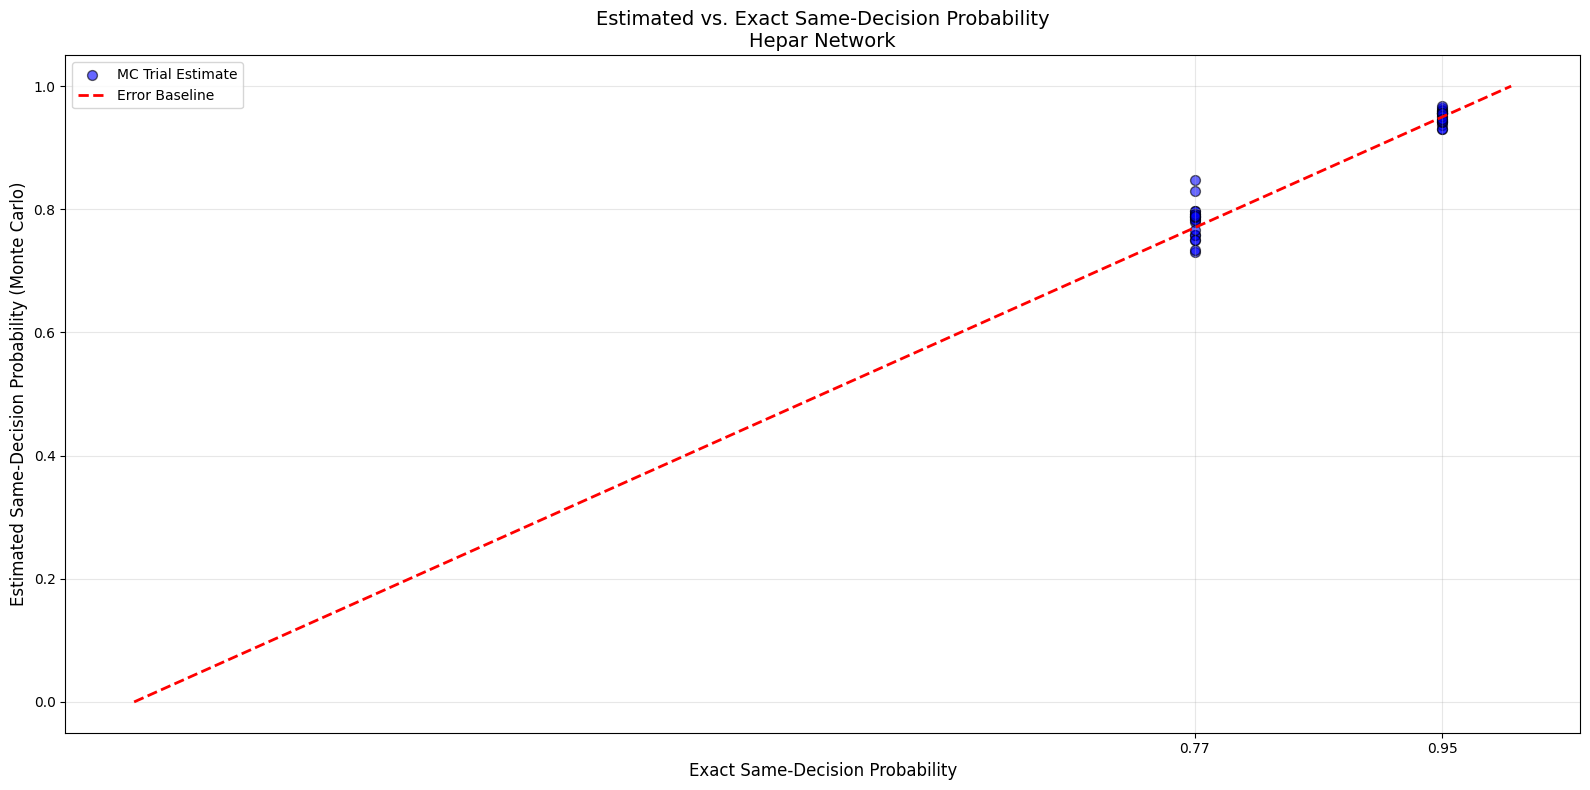

In [93]:
plot_experiment_results_exact_vs_est(hepar_results, 'Hepar')

excesso de confiança no modelo já aprendido (estrutura)
a d-separação pode não estar correta